## <strong>第四次作品：卷積神經網路 CNN 在影像辨識與超解析生成的練習</strong>
作業編號：4

學號：711133108

姓名：林楷博
<hr>

 <font color=skyblue>作品目標</font>：

- 了解上課下載的程式碼在做什麼事：
    - 訓練 SRCNN 模型：程式碼會將訓練數據集中的低分辨率影像作為輸入，並將對應的高分辨率影像作為目標輸出。通過反向傳播和優化算法，模型會嘗試最小化輸出影像與目標影像之間的差異，從而學習如何從低分辨率影像中生成高分辨率影像。
- 記錄與上課下載的程式碼不同之處：
    - 進一步訓練模型： 在已訓練的模型上進行額外的訓練。這可以透過加載預訓練的權重並繼續訓練幾個額外的 epoch 來實現。
    - 測試模型性能： 對訓練完成的模型進行測試，計算其在測試數據集上的 PSNR 值。這有助於評估模型的性能和泛化能力。
    - 實際應用模型： 使用訓練完成的模型對任意選擇的影像進行優化，並與 Bicubic 方法進行對比，更直觀地比較模型的效果。
- 了解 CNN 模型的應用：
    - 通過訓練 SRCNN 模型，可以學習如何使用卷積神經網絡來解決圖像超分辨率的問題，即如何從低分辨率的影像中生成高分辨率的影像，了解CNN 模型在圖像處理領域中的重要應用。
- 熟悉 PyTorch 的語法：
    - 通過閱讀和實作 PyTorch 中的相關程式碼，可以熟悉 PyTorch 的基本語法。這有助於理解如何構建、訓練和測試深度學習模型，以及如何進行數據加載、優化器配置等操作。

## <font color=orange>SRCNN（Super-Resolution Convolutional Neural Network）</font>：<br>
一種用於圖像超分辨率重建的深度學習模型。其主要目標是通過從低分辨率圖像生成高分辨率圖像來提高圖像的細節和清晰度。SRCNN 是由研究人員 Chao Dong等人在2014年提出的，其主要內容包括：

- 目標：該研究的目標是通過學習一種端到端(end-to-end)的映射方式，從低分辨率圖像生成高分辨率圖像，利用深度卷積神經網絡（CNN）來實現這一目標。
- 方法：提出的方法稱為「超分辨率卷積神經網絡」（Super-Resolution Convolutional Neural Network, SRCNN）。這種方法與傳統的超分辨率方法不同，它將所有步驟整合到一個統一的深度學習框架中，而不是分開優化每個組件。
- 過程：
    - 補丁提取和表示：從低分辨率圖像中提取重疊的圖像塊，並將每個圖像塊表示為高維向量。
    - 非線性映射：將這些高維向量映射到另一組高維向量，這些高維向量代表高分辨率圖像塊。
    - 重建：聚合這些高分辨率圖像塊，以生成最終的高分辨率圖像。
- 優點：
    - SRCNN具有輕量級結構，且提供了最先進的圖像修復質量。
    - 隨著數據集的增大和更多的訓練，模型性能進一步提高。
    - SRCNN模型易於實現，並且可以利用現代GPU和大型數據集高效訓練。
- 比較模型/方法
    - 透過Bicubic放大恢復同等尺寸的影像(目前商業最常使用的方法)
    - SC [26]
    - K-SVD [28]
    - NE+NNLS [2] 
    - NE+LLE [4]
    - ANR [20]
    - SRCNN模型進行比較。
- 結果：    
    - 提出的SRCNN方法在峰值信噪比（PSNR）方面超過了雙三次插值和其他模型。

<font color = gray size = 3>資料來源：https://debuggercafe.com/image-super-resolution-using-deep-convolutional-networks-paper-explanation/ </font>

---

### **<font color=skyblue>(1)：資料生成(patchify_image.py)</font>**
- 因CNN模型屬於監督式機器學習，因此在模型生成過程中，需要已知答案的數據，即同一張照片同尺寸的高解析度和低解析度版本。高解析度的照片作為模型的標籤（答案），低解析度的照片作為模型的輸入。然而，在實務中，很少有這類配對數據，因此需要自行生成。
- 想法:
將原始的高解析度圖片縮小 n 倍，接著使用雙三次插值方法(bicubic.py)將這個經過縮小的圖片放大 n 倍，這樣就可以得到與原圖同尺寸的低解析度圖片。

- 將這些生成的低解析度圖片與高解析度圖片透過patchify.patchify()將輸入的圖像切割成指定大小的小塊，小塊的低解析度圖片用作模型的輸入，而對應小塊的原始的高解析度圖片則作為模型的標籤進行訓練。

- 與上課程式碼不同之處:
    - 縮放三倍

```python
# Convert to bicubic and save.(縮小3倍)
h, w, _ = patch.shape
low_res_img = cv2.resize(patch, (int(w*1/3), int(h*1/3)), 
                        interpolation=cv2.INTER_CUBIC)

# Now upscale using BICUBIC.(放大3倍)
high_res_upscale = cv2.resize(low_res_img, (w, h), 
                            interpolation=cv2.INTER_CUBIC)
```

### **<font color=skyblue>(2)：完整圖形的輸入與輸出準備(bicubic.py)</font>**
- 與訓練集相同，使用原始高解析度圖片，將這些圖片縮小三倍後透過bicubic放大回原本尺寸，藉由此步驟模擬模糊的圖像。這樣可以確保模型在訓練期間能夠學習從模糊的低解析度圖像中恢復出高解析度圖像的細節和清晰度。
- 超參數設定
    - parser.add_argument：這是向參數解析器添加參數的方法。透過呼叫這個方法，可以定義需要在命令列中接受的參數。
    - '-p', '--path'：這是參數的名稱，其中 -p 是參數的簡寫，--path 是參數的完整寫法。在命令列中，可以使用 -p 或 --path 來指定該參數。
    - default='../input/Set14/original'：這是參數的預設值。如果使用者在命令列中沒有明確指定 -p 參數，那麼將會使用這個預設值。在這裡，預設的高解析度圖片路徑被設定為 '../input/Set14/original'。
    - nargs='+'：這個參數告訴解析器接受一個以上的參數值。換句話說，-p 參數後面可以跟隨一個或多個路徑，而不僅僅是單個路徑。
    - help='path to the high-res images to convert to low-res'：這是關於參數作用的簡要描述。當使用者執行腳本時，可以透過使用 -h 或 --help 參數來獲取這些說明資訊。

```python 
parser.add_argument('-p', '--path', default='../input/Set14/original', 
                    nargs='+',
                    help='path to the high-res images to convert to low-res')
```
- 與上課程式碼不同之處:
```python 
args['scale_factor'] == '3x':
```

###  **<font color=skyblue>(3)：模型架構(srcnn.py)</font>**
- `__init__` 方法：
定義了模型的各個層，包括三個卷積層 (conv1, conv2, conv3)。
- 卷積層 (nn.Conv2d) 的定義：
    - conv1：輸入通道數為 3（RGB），輸出通道數為 64，卷積核大小為 9x9。
    - conv2：輸入通道數為 64，輸出通道數為 32，卷積核大小為 1x1。
    - conv3：輸入通道數為 32，輸出通道數為 3，卷積核大小為 5x5。
- forward 方法：
    - 複製輸入 x 作為 identity。
    - 將 x 通過 conv1、conv2 和 conv3 三個卷積層。
    - 對每個卷積層的輸出應用 ReLU 激活函數。
    - 將 conv3 的輸出和 identity 相加，得到模型的輸出 out。
- 卷積運算的設定：
    - 卷積核大小、步幅（stride）和填充（padding）在每個卷積層中都有不同的設置，用來控制特徵圖的大小和特徵提取的方式。
- 實作

```python
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=9, stride=(1, 1), padding=(2, 2)
        )
        self.conv2 = nn.Conv2d(
            64, 32, kernel_size=1, stride=(1, 1), padding=(2, 2)
        )
        self.conv3 = nn.Conv2d(
            32, 3, kernel_size=5, stride=(1, 1), padding=(2, 2)
        )
        #stride移動間隔 padding多出的格數
        #conv3中第二個3是因為3個(RGB)
        #透過後續超參數調整輸入與輸出的通道數相同
        #實算:輸入32，kernel_size=5，所以32-5+1=28，透過padding=(2, 2)，調整輸出格式28+2*2=32
```

- 與上課程式碼不同之處:
    - Kim等人在2015年的工作建立在Chao Dong等人在2014年提出的模型之上，他們提出了一種改進的方法來進一步提高模型的性能。這種方法的核心思想是將模糊影像與殘差影像相結合，以便在訓練過程中模型能夠學習到更多的細節信息。
    - 使用2015年的概念用類似於補差（residual learning）的方法，其中模型的輸出是原始影像與模糊影像之間的差異。

```python
def forward(self, x):
    identity = x
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.conv3(x)
    out = torch.add(x,identity)
    return out
```

###  **<font color=skyblue>(4)：模型訓練(train_5.py)</font>**
- 從全新模型開始訓練
- 參數調整:
    - 優化器選擇Adam
    - 損失函數選擇MSE
- 為求版面，在此僅呈現最前面與最後面各10次的Train PSNR與Val PSNR值，並且因欲了解當下模型訓練進度，中間還是呈現出當下在執行的Epoch數
- 在此作品這部分執行500次的 epochs
### **<font color=skyblue>(5)接續訓練第2次</font>**
- 載入已訓練好的模型權重，並再接著訓練
- 有時由於各種原因，訓練一個深度神經網絡需要很長時間。如果訓練過程中斷，希望從上次停止的地方繼續訓練，這時就需要載入之前已經訓練好的模型權重。
- 在此作品這部分執行100次的 epochs
- 與上課程式碼不同之處:
    - 程式碼(1)為上課程式碼，但在儲存時沒有'model_state_dict'項，會導致KeyError: 'model_state_dict'，因此改由程式碼(2)來解決此問題

```python
model.load_state_dict(checkpoint['model_state_dict'])#(1)
model.load_state_dict(torch.load(args['weights']))#(2)
```

### **<font color=skyblue>(6)將已訓練好的模型應用於測試集部分(test_6.py)</font>**
- 在此領域常用Set5與Set14兩組資料作為評比的樣本
- 比較基準
    - 模型測試時長
    - 驗證集樣本平均解析度PSNR值 (dB)(值越大越好)
        - $PSNR=10\cdot\log_{10}\left(\frac{MAX_I^2}{MSE}\right)=20\cdot\log_{10}\left(\frac{MAX_I}{\sqrt{MSE}}\right)$，其中$MAX_I$是圖像像素值的最大可能值，通常是255，MSE 是均方誤差（Mean Squared Error），表示原始圖像和模糊圖像之間每個像素差異的平方和的均值。
- 與(2)相同，將評比樣本縮小n倍後再透過BICUBIC放大回同尺寸的模糊影像套用進已訓練好的模型，最後平均整組資料PSNR值查看結果

### **<font color=skyblue>(7)將已訓練好的模型應用於自行找的影像</font>**
- 自行挑選一張影像，將之壓縮3倍，並透過Bicubic放大3倍後作為模型的輸入
- 將上述影像轉換為torch的格式輸入模型中，並將輸出轉回numpy的格式呈現影像結果
- 呈現出Bicubic與模型輸出的影像的PSNR值做比較

## (1)資料生成(patchify_image.py)

In [1]:
%run patchify_image_1.py 

Creating patches for 91 images


100%|██████████| 91/91 [00:11<00:00,  7.80it/s]


## (2)：完整圖形的輸入與輸出準備(bicubic.py)

In [2]:
%run bicubic_2.py -p ../input/Set14/original ../input/Set5/original -s 3x 

C:\Users\jameslin\Documents\python\淺度機器學習\SRCNN\練習\src\bicubic_2.py:59: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  low_res_img = orig_img.resize((int(w*scale_factor), int(h*scale_factor)), Image.BICUBIC)
C:\Users\jameslin\Documents\python\淺度機器學習\SRCNN\練習\src\bicubic_2.py:61: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  high_res_upscale = low_res_img.resize((w, h), Image.BICUBIC)


19
Scaling factor: 3x
Low resolution images save path: ../input/test_bicubic_rgb_3x
Original image dimensions: 500, 480
Original image dimensions: 720, 576
Original image dimensions: 512, 512
Original image dimensions: 352, 288
Original image dimensions: 250, 361
Original image dimensions: 276, 276
Original image dimensions: 500, 362
Original image dimensions: 352, 288
Original image dimensions: 512, 512
Original image dimensions: 512, 512
Original image dimensions: 768, 512
Original image dimensions: 512, 512
Original image dimensions: 529, 656
Original image dimensions: 586, 391
Original image dimensions: 512, 512
Original image dimensions: 288, 288
Original image dimensions: 256, 256
Original image dimensions: 280, 280
Original image dimensions: 228, 344


## (3)：模型架構(srcnn.py) 可不跑

In [3]:
%run srcnn_4.py 

20,099 total parameters.
20,099 training parameters.


## (4)：模型訓練(train_5.py)

In [4]:
%run train_5.py --epochs 500

Computation device:  cuda
SRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)
Training samples: 22227
Validation samples: 19
Epoch 1 of 500


  0%|          | 0/174 [00:00<?, ?it/s]c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Train PSNR: 24.525
Val PSNR: 26.076
Saving model...
Epoch 2 of 500


Train PSNR: 24.731
Val PSNR: 26.163
Saving model...
Epoch 3 of 500


Train PSNR: 24.794
Val PSNR: 26.286
Saving model...
Epoch 4 of 500


...

Train PSNR: 25.268
Val PSNR: 26.465
Saving model...
Epoch 497 of 500


Train PSNR: 25.269
Val PSNR: 26.553
Saving model...
Epoch 498 of 500


Train PSNR: 25.264
Val PSNR: 26.549
Saving model...
Epoch 499 of 500


Train PSNR: 25.265
Val PSNR: 26.598
Saving model...
Epoch 500 of 500


Train PSNR: 25.268
Val PSNR: 26.535
Saving model...
Finished training in: 91.005 minutes


## (5)接續訓練第2次

In [5]:
%run train_5.py --weights ../outputs/model.pth --epochs 100

Computation device:  cuda
Loading weights to resume training...
SRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)
Training samples: 22227
Validation samples: 19
Epoch 1 of 100


Train PSNR: 25.261
Val PSNR: 26.546
Saving model...
Epoch 2 of 100


Train PSNR: 25.273
Val PSNR: 26.590
Saving model...
Epoch 3 of 100


Train PSNR: 25.267
Val PSNR: 26.521
Saving model...
Epoch 4 of 100


Train PSNR: 25.260
Val PSNR: 26.514
Saving model...
Epoch 5 of 100


...

Train PSNR: 25.273
Val PSNR: 26.579
Saving model...
Epoch 97 of 100


Train PSNR: 25.273
Val PSNR: 26.517
Saving model...
Epoch 98 of 100


Train PSNR: 25.276
Val PSNR: 26.529
Saving model...
Epoch 99 of 100


Train PSNR: 25.271
Val PSNR: 26.527
Saving model...
Epoch 100 of 100


Train PSNR: 25.277
Val PSNR: 26.551
Saving model...
Finished training in: 17.994 minutes


## (6)將已訓練好的模型應用於測試集部分(test_6.py)

In [6]:
%run test_6.py

  0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\jameslin\Documents\python\淺度機器學習\SRCNN\練習\src\test_6.py:43: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  low_res_img = label.resize((int(w*1/3), int(h*1/3)), Image.BICUBIC)
C:\Users\jameslin\Documents\python\淺度機器學習\SRCNN\練習\src\test_6.py:45: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  image = low_res_img.resize((w, h), Image.BICUBIC)
100%|██████████| 5/5 [00:00<00:00, 60.23it/s]


Test PSNR on Set5: 28.719


100%|██████████| 14/14 [00:00<00:00, 34.58it/s]

Test PSNR on Set14: 25.803


### **<font color=skyblue>結果的觀察與討論：</font>**
將已訓練好的模型應用於測試集Set5與Set14部分(test_6.py)，得到各自PSNR值
- Set5的平均PSNR值為: 28.719
- Set14的平均PSNR值為: 25.803

## (7)將已訓練好的模型應用於自行找的影像

C:\Users\jameslin\AppData\Local\Temp\ipykernel_15532\1251782705.py:22: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  low_res_img = label.resize((int(w*1/3), int(h*1/3)), Image.BICUBIC)
C:\Users\jameslin\AppData\Local\Temp\ipykernel_15532\1251782705.py:23: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  image = low_res_img.resize((w, h), Image.BICUBIC)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


PSNR score of the input image: 34.782


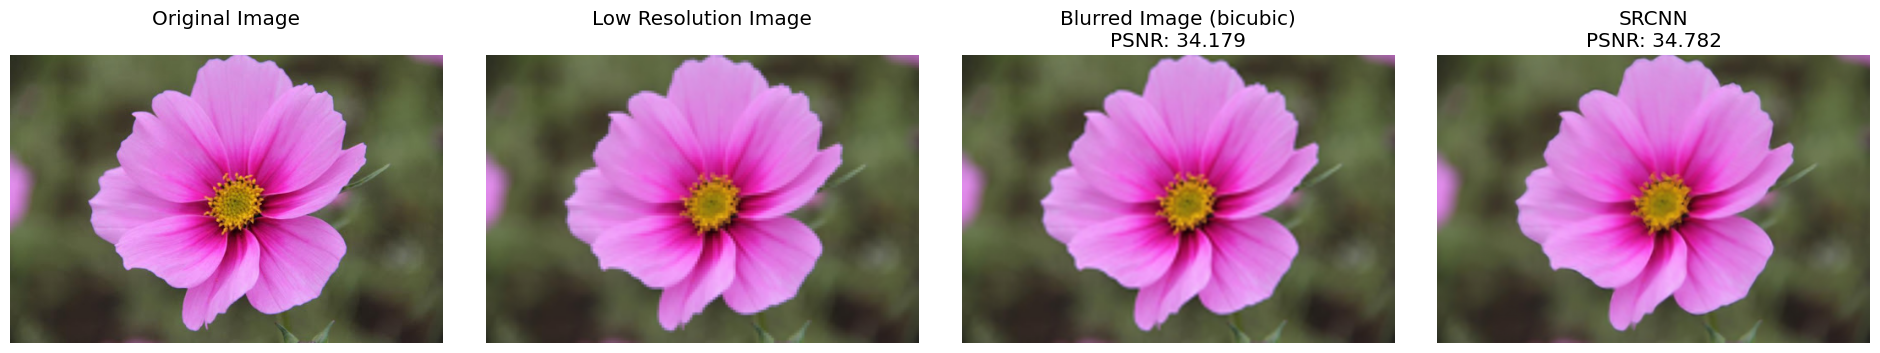

In [66]:
import torch
import numpy as np
from PIL import Image
from srcnn_4 import SRCNN
from utils_0 import psnr
import matplotlib.pyplot as plt
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SingleImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_path):
        self.image_path = image_path

    def __len__(self):
        return 1

    def __getitem__(self, index):
        label = Image.open(self.image_path).convert('RGB')
        w, h = label.size[:]
        low_res_img = label.resize((int(w*1/3), int(h*1/3)), Image.BICUBIC)
        image = low_res_img.resize((w, h), Image.BICUBIC)

        image = np.array(image, dtype=np.float32)
        low_res_img = np.array(low_res_img, dtype=np.float32)
        label = np.array(label, dtype=np.float32)

        image /= 255.
        low_res_img /= 255.
        label /= 255.

        image = image.transpose([2, 0, 1])
        low_res_img = low_res_img.transpose([2, 0, 1])
        label = label.transpose([2, 0, 1])

        return (
            torch.tensor(image, dtype=torch.float),
            torch.tensor(low_res_img, dtype=torch.float),
            torch.tensor(label, dtype=torch.float)
        )

if __name__ == '__main__':
    # 要輸入的圖片路徑
    input_image_path = '../input/test.png'
    
    # 加載模型
    model = SRCNN()
    checkpoint = torch.load('../outputs/model.pth')
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()

    # 創建資料集
    single_image_dataset = SingleImageDataset(input_image_path)
    # 創建資料載入器
    single_image_loader = torch.utils.data.DataLoader(
        single_image_dataset,
        batch_size=1,
        shuffle=False
    )

    # 驗證模型
    for inputs, low_res_imgs, labels in single_image_loader:
        inputs, low_res_imgs, labels = inputs.to(device), low_res_imgs.to(device), labels.to(device)
        outputs = model(inputs)
        psnr_score = psnr(labels, outputs)
        print(f"PSNR score of the input image: {psnr_score:.3f}")
        
        # 轉換為 numpy 陣列並調整形狀
        original_image = labels.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
        low_res_img_np = low_res_imgs.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
        blurred_image = inputs.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
        model_output = outputs.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
                
        # 顯示圖片和 PSNR 值
        fig, axs = plt.subplots(1, 4, figsize=(24, 6))
        
        axs[0].imshow(original_image)
        axs[0].set_title(f'Original Image\n')
        axs[0].axis('off')
        
        axs[1].imshow(low_res_img_np)
        axs[1].set_title(f'Low Resolution Image\n')
        axs[1].axis('off')
        
        axs[2].imshow(blurred_image)
        axs[2].set_title(f'Blurred Image (bicubic)\nPSNR: {psnr(labels, inputs):.3f}')
        axs[2].axis('off')
        
        axs[3].imshow(model_output)
        axs[3].set_title(f'SRCNN\nPSNR: {psnr(labels, outputs):.3f}')
        axs[3].axis('off')
        
        plt.subplots_adjust(wspace=0.1)  # 调整子图之间的宽度间隔
        plt.show()


### **<font color=skyblue>結果的觀察與討論(總結)：</font>**
- 本作品於訓練模型共執行600次的 epochs
- 將已訓練好的模型應用於自行找的圖片，並與bicubic的方式做比較:
    - 第一張圖為原始圖片(即清晰圖片)
    - 第二張圖為原始圖片尺寸縮小3倍後，直接使用plt套件放大回原尺寸後的圖片
    - 第三張圖為原始圖片尺寸縮小3倍後，再使用bicubic放大回原尺寸後的圖片
    - 第四張圖為第三張圖片經SRCNN模型優化後的圖片
- 可以清楚了解到幾件事:
    - 第四張圖(SRCNN)有最好的表現(最高的PSNR值)
    - 第三張圖(bicubic)略輸第四張圖一些，但整體效果還不錯
    - 第二張圖就有些模糊，呈現效果較差
- 綜上所述，透過這些比較，可以清楚地瞭解到 SRCNN 模型在圖像超解析度任務上的優越性，以及與傳統方法（如 bicubic）相比的優勢。這也突顯了深度學習在圖像處理領域中的重要性和應用前景。